In [10]:
import pandas as pd
import matplotlib.pyplot as plt 

df = pd.read_parquet("../data/dataset.parquet")
df['timestamp'] = pd.to_datetime(df['timestamp'])

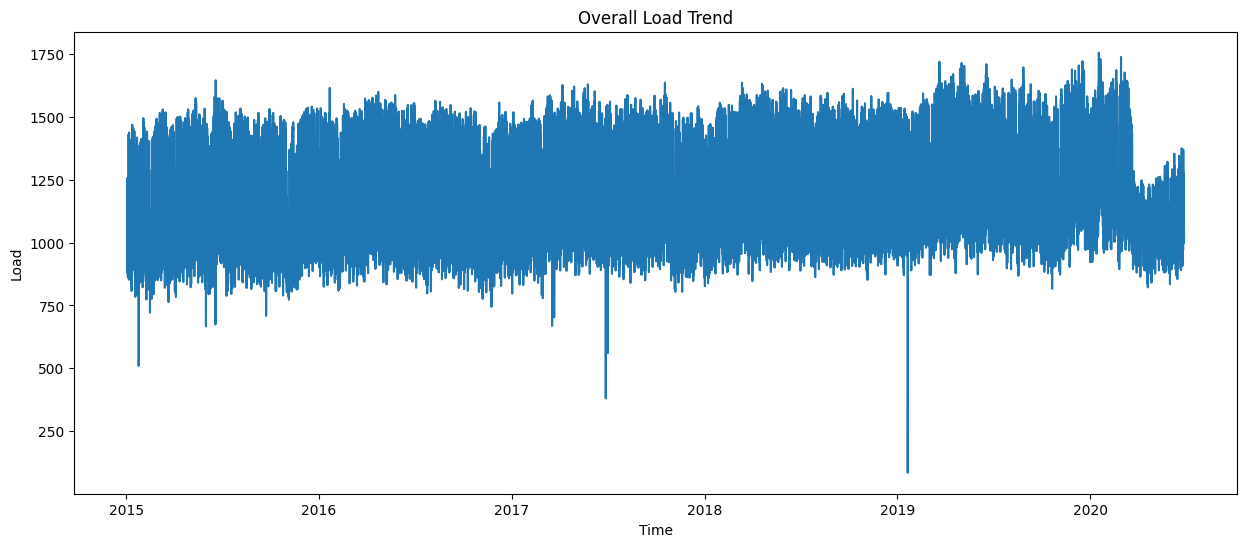

In [11]:
### Plot Overall Load Trend 
plt.figure(figsize=(15,6 ))
plt.plot(df['timestamp'], df['load'])
plt.title("Overall Load Trend")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()

In [12]:
# Create basic time features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['year'] = df['timestamp'].dt.year

In [13]:
df.head()

,timestamp,load,temperature,humidity,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,...,TQL_dav,W2M_dav,Holiday_ID,holiday,school,hour,day_of_week,month,day,year
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,...,0.096100,5.364148,0,0,0,1,5,1,3,2015
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,...,0.087646,5.572471,0,0,0,2,5,1,3,2015
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,...,0.078735,5.871184,0,0,0,3,5,1,3,2015
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,...,0.068390,5.883621,0,0,0,4,5,1,3,2015
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,...,0.064362,5.611724,0,0,0,5,5,1,3,2015


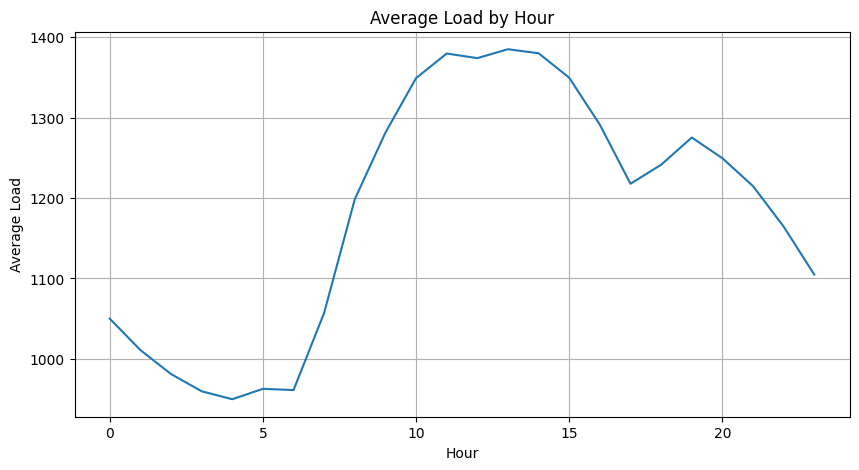

In [15]:
# Average Load by hour 
hourly_avg = df.groupby('hour')["load"].mean()
plt.figure(figsize=(10,5))
hourly_avg.plot()
plt.title("Average Load by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Load")
plt.grid()
plt.show()

In [16]:
"""
It is pretty evident from the graph that :
There is a rise in load during the morning hours (6 AM to 9 AM) 
and evening hours (5 PM to 8 PM). 
This is likely due to increased activity in households and businesses during these times, such as cooking, heating, and lighting.
"""

'\nIt is pretty evident from the graph that :\nThere is a rise in load during the morning hours (6 AM to 9 AM) \nand evening hours (5 PM to 8 PM). \nThis is likely due to increased activity in households and businesses during these times, such as cooking, heating, and lighting.\n'

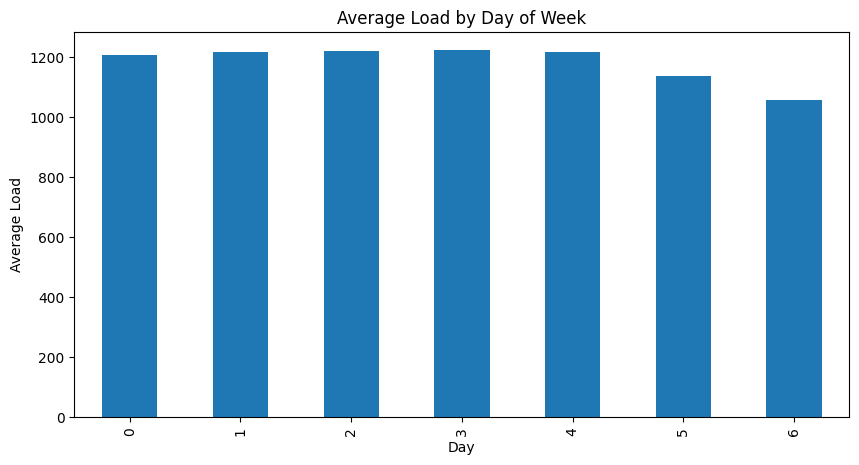

In [18]:
### Lets see the average load by day of week 
weekday_avg = df.groupby("day_of_week")["load"].mean()

plt.figure(figsize=(10,5))
weekday_avg.plot(kind="bar")
plt.title("Average Load by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Load")
plt.show()

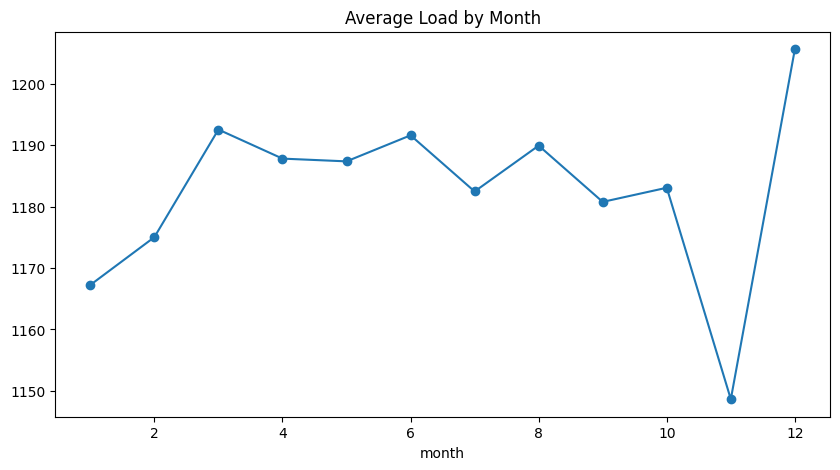

In [19]:
### Monthly Trend
monthly_avg = df.groupby("month")["load"].mean()

plt.figure(figsize=(10,5))
monthly_avg.plot(marker="o")
plt.title("Average Load by Month")
plt.show()

In [22]:
### Outlier Detection
q1 = df["load"].quantile(0.25)
q3 = df["load"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["load"] < lower) | (df["load"] > upper)]

print(outliers.shape)
outliers.head()

(7, 22)


,timestamp,load,temperature,humidity,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,...,TQL_dav,W2M_dav,Holiday_ID,holiday,school,hour,day_of_week,month,day,year
520,2015-01-24 17:00:00,509.8358,27.034692,0.016271,0.194885,22.125257,28.706567,0.016065,0.099915,7.182586,...,0.086212,0.728335,0,0,0,17,5,1,24,2015
21755,2017-06-27 12:00:00,380.5936,28.446252,0.017640,0.113861,5.408851,27.977502,0.019158,0.256470,5.553203,...,0.255127,3.294285,0,0,1,12,1,6,27,2017
35483,2019-01-20 12:00:00,85.1925,29.394678,0.016237,0.033951,24.225527,29.144678,0.016504,0.202942,12.431692,...,0.050812,1.413640,0,0,0,12,6,1,20,2019
35484,2019-01-20 13:00:00,135.7636,29.294672,0.016032,0.062653,24.641796,29.372797,0.016513,0.125244,14.316523,...,0.084290,1.615353,0,0,0,13,6,1,20,2019
35485,2019-01-20 14:00:00,263.6183,28.969019,0.015850,0.067841,25.936263,29.547144,0.016460,0.057800,15.979043,...,0.114075,1.949015,0,0,0,14,6,1,20,2019


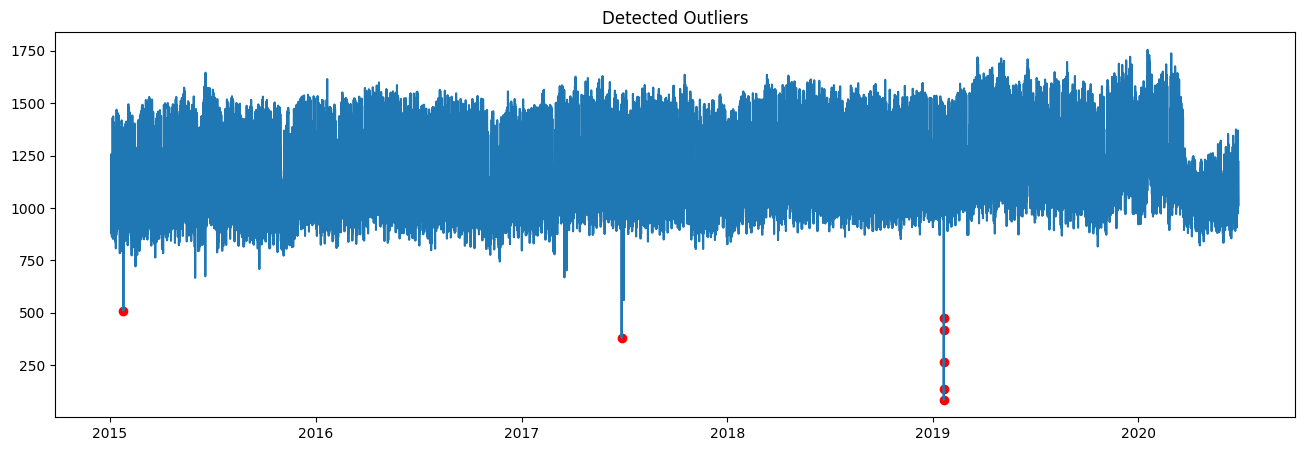

In [23]:
plt.figure(figsize=(16,5))
plt.plot(df["timestamp"], df["load"])
plt.scatter(outliers["timestamp"], outliers["load"], color="red")
plt.title("Detected Outliers")
plt.show()

In [24]:
### We are not removing Them for anomaly detection